In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/company-bankruptcy-prediction/data.csv


In [2]:
!pip install yfinance shap chromadb sentence-transformers transformers accelerate scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 66.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 89.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are instal

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.cluster import KMeans
from scipy.stats import spearmanr
import shap
import matplotlib.pyplot as plt
import time

In [4]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/company-bankruptcy-prediction/data.csv")
df.columns = [c.strip() for c in df.columns]
X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train_capped = X_train.copy()
X_test_capped = X_test.copy()
cap_bounds = {}
for col in X_train_capped.columns:
    lower, upper = X_train_capped[col].quantile([0.01, 0.99])
    cap_bounds[col] = (lower, upper)
    X_train_capped[col] = X_train_capped[col].clip(lower, upper)
    X_test_capped[col] = X_test_capped[col].clip(lower, upper)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

credit_model = LogisticRegression(max_iter=2000, class_weight="balanced")
credit_model.fit(X_train_scaled, y_train)
preds = credit_model.predict(X_test_scaled)
probs = credit_model.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, preds))
print("Raw AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94      1320
           1       0.20      0.89      0.33        44

    accuracy                           0.88      1364
   macro avg       0.60      0.89      0.63      1364
weighted avg       0.97      0.88      0.92      1364

Raw AUC: 0.9485709366391185


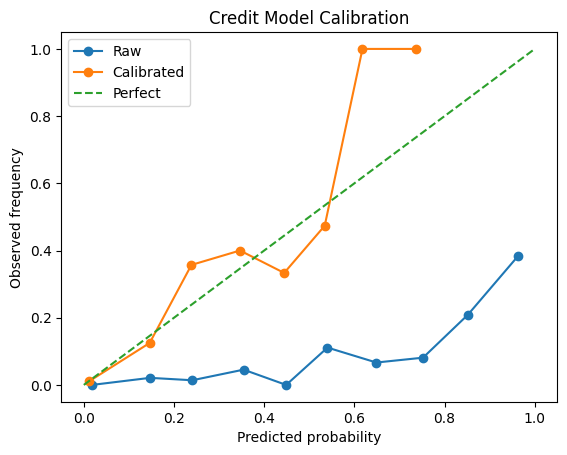

Calibrated AUC: 0.9485451101928375


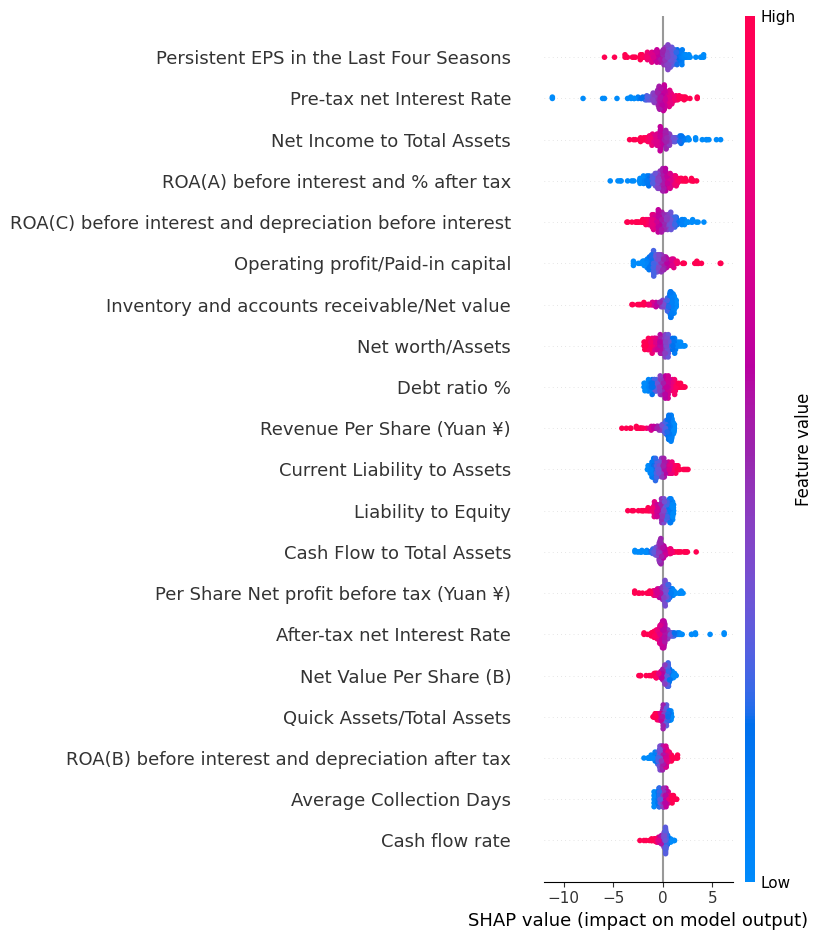

In [5]:
calibrated_model = CalibratedClassifierCV(credit_model, method="isotonic", cv=5)
calibrated_model.fit(X_train_scaled, y_train)
calibrated_probs = calibrated_model.predict_proba(X_test_scaled)[:, 1]

prob_true_raw, prob_pred_raw = calibration_curve(y_test, probs, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_probs, n_bins=10)

plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.title("Credit Model Calibration")
plt.show()

print("Calibrated AUC:", roc_auc_score(y_test, calibrated_probs))

explainer = shap.LinearExplainer(credit_model, X_train_scaled, feature_names=X.columns)
shap_values = explainer(X_test_scaled[:200])
shap.summary_plot(shap_values, X_test_capped.iloc[:200], show=True)

In [6]:
nifty_500_url = "https://archives.nseindia.com/content/indices/ind_nifty500list.csv"
nifty_500 = pd.read_csv(nifty_500_url)

filtered = nifty_500[nifty_500["Industry"] == "Metals & Mining"]
tickers = [f"{sym}.NS" for sym in filtered["Symbol"].tolist()]
sector_map = dict(zip(tickers, ["Metals & Mining"] * len(tickers)))

print(f"Total tickers: {len(tickers)}")
tickers

Total tickers: 18


['ADANIENT.NS',
 'GRAVITA.NS',
 'GMDCLTD.NS',
 'HINDALCO.NS',
 'HINDCOPPER.NS',
 'HINDZINC.NS',
 'JSWSTEEL.NS',
 'JAINREC.NS',
 'JSL.NS',
 'JINDALSTEL.NS',
 'LLOYDSME.NS',
 'NMDC.NS',
 'NSLNISP.NS',
 'NATIONALUM.NS',
 'SARDAEN.NS',
 'SAIL.NS',
 'TATASTEEL.NS',
 'VEDL.NS']

In [7]:
def fetch_financials(ticker):
    try:
        stock = yf.Ticker(ticker)
        return {
            "info": stock.info,
            "balance_sheet": stock.balance_sheet,
            "financials": stock.financials,
            "cashflow": stock.cashflow,
            "news": stock.news
        }
    except Exception as e:
        print(f"Failed for {ticker}: {e}")
        return None

raw_data = {}
for i, t in enumerate(tickers):
    result = fetch_financials(t)
    if result is not None and result["info"].get("currentPrice") is not None:
        raw_data[t] = result
    if i % 10 == 0:
        time.sleep(1)

credit_scoring_universe = [t for t in tickers if t in raw_data]
print(f"Successfully fetched: {len(credit_scoring_universe)}")
credit_scoring_universe

Successfully fetched: 18


['ADANIENT.NS',
 'GRAVITA.NS',
 'GMDCLTD.NS',
 'HINDALCO.NS',
 'HINDCOPPER.NS',
 'HINDZINC.NS',
 'JSWSTEEL.NS',
 'JAINREC.NS',
 'JSL.NS',
 'JINDALSTEL.NS',
 'LLOYDSME.NS',
 'NMDC.NS',
 'NSLNISP.NS',
 'NATIONALUM.NS',
 'SARDAEN.NS',
 'SAIL.NS',
 'TATASTEEL.NS',
 'VEDL.NS']

In [8]:
def compute_manual_beta(ticker, benchmark="^NSEI", period="3y"):
    stock_hist = yf.download(ticker, period=period, progress=False)["Close"]
    bench_hist = yf.download(benchmark, period=period, progress=False)["Close"]
    combined = pd.concat([stock_hist, bench_hist], axis=1, join="inner")
    combined.columns = ["stock", "benchmark"]
    returns = combined.pct_change().dropna()
    if len(returns) < 100:
        return None
    covariance = returns["stock"].cov(returns["benchmark"])
    benchmark_variance = returns["benchmark"].var()
    return covariance / benchmark_variance

manual_betas = {}
for t in credit_scoring_universe:
    try:
        manual_betas[t] = compute_manual_beta(t)
    except Exception as e:
        print(f"Failed for {t}: {e}")
        manual_betas[t] = None

pd.DataFrame({"Ticker": credit_scoring_universe, "manual_beta": [manual_betas[t] for t in credit_scoring_universe]})

/tmp/ipykernel_58/582826686.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_hist = yf.download(ticker, period=period, progress=False)["Close"]
/tmp/ipykernel_58/582826686.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bench_hist = yf.download(benchmark, period=period, progress=False)["Close"]
/tmp/ipykernel_58/582826686.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_hist = yf.download(ticker, period=period, progress=False)["Close"]
/tmp/ipykernel_58/582826686.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bench_hist = yf.download(benchmark, period=period, progress=False)["Close"]
/tmp/ipykernel_58/582826686.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_hist = yf.download(ticker, period=period, progress=False)["Close"]
/tmp/ipykernel_58/582826686.py:3: FutureWarning: YF.downloa

,Ticker,manual_beta
0,ADANIENT.NS,1.736871
1,GRAVITA.NS,1.449828
2,GMDCLTD.NS,1.599413
3,HINDALCO.NS,1.086485
4,HINDCOPPER.NS,1.885364
5,HINDZINC.NS,1.102111
6,JSWSTEEL.NS,1.237887
7,JAINREC.NS,0.659328
8,JSL.NS,1.106030
9,JINDALSTEL.NS,1.220040


In [9]:
def compute_historical_growth(ticker, years_lookback=4, min_growth=0.02, max_growth=0.12):
    fin = raw_data[ticker]["financials"]
    try:
        revenue_series = fin.loc["Total Revenue"].iloc[:years_lookback].dropna()
    except:
        return 0.06
    if len(revenue_series) < 2:
        return 0.06
    revenue_series = revenue_series.iloc[::-1]
    start_rev, end_rev = revenue_series.iloc[0], revenue_series.iloc[-1]
    n_periods = len(revenue_series) - 1
    if start_rev <= 0 or n_periods == 0:
        return 0.06
    cagr = (end_rev / start_rev) ** (1 / n_periods) - 1
    return np.clip(cagr, min_growth, max_growth)

historical_growth_rates = {}
for t in credit_scoring_universe:
    try:
        historical_growth_rates[t] = compute_historical_growth(t)
    except Exception as e:
        historical_growth_rates[t] = 0.06

pd.DataFrame({"Ticker": credit_scoring_universe, "Growth Rate": [historical_growth_rates[t] for t in credit_scoring_universe]})

,Ticker,Growth Rate
0,ADANIENT.NS,0.020000
1,GRAVITA.NS,0.120000
2,GMDCLTD.NS,0.020000
3,HINDALCO.NS,0.070996
4,HINDCOPPER.NS,0.120000
5,HINDZINC.NS,0.056103
6,JSWSTEEL.NS,0.036139
7,JAINREC.NS,0.120000
8,JSL.NS,0.064859
9,JINDALSTEL.NS,0.020000


In [10]:
def rescale_to_training_range(value, train_col):
    train_min, train_max = df[train_col].quantile([0.01, 0.99])
    if train_col == "Debt ratio %":
        real_min, real_max = 0.0, 1.0
    elif train_col == "Net Income to Total Assets":
        real_min, real_max = -0.2, 0.3
    elif train_col == "Current Ratio":
        real_min, real_max = 0.0, 5.0
    normalized = (value - real_min) / (real_max - real_min)
    return train_min + normalized * (train_max - train_min)

def build_credit_features(ticker):
    info = raw_data[ticker]["info"]
    bs = raw_data[ticker]["balance_sheet"]
    fin = raw_data[ticker]["financials"]
    total_assets = bs.loc["Total Assets"].iloc[0]
    total_liabilities = bs.loc["Total Liabilities Net Minority Interest"].iloc[0]
    net_income = fin.loc["Net Income"].iloc[0]
    current_assets = bs.loc["Current Assets"].iloc[0]
    current_liabilities = bs.loc["Current Liabilities"].iloc[0]

    debt_ratio = total_liabilities / total_assets
    ni_to_assets = net_income / total_assets
    current_ratio = current_assets / current_liabilities

    feature_vector = np.zeros(len(X.columns))
    rescaled_map = {
        "Debt ratio %": rescale_to_training_range(debt_ratio, "Debt ratio %"),
        "Net Income to Total Assets": rescale_to_training_range(ni_to_assets, "Net Income to Total Assets"),
        "Current Ratio": rescale_to_training_range(current_ratio, "Current Ratio")
    }
    for col, val in rescaled_map.items():
        idx = list(X.columns).index(col)
        lower, upper = cap_bounds[col]
        feature_vector[idx] = np.clip(val, lower, upper)
    return feature_vector.reshape(1, -1)

In [11]:
CORPORATE_ACTION_EXCLUSIONS = {
    "VEDL.NS": "5-way demerger effective May 1 2026, financials reflect pre-demerger combined entity"
}
MAX_TERMINAL_VALUE_SHARE = 0.80

def get_avg_fcf(ticker, years_lookback=3, max_volatility_ratio=1.5):
    cf = raw_data[ticker]["cashflow"]
    try:
        fcf_series_full = cf.loc["Free Cash Flow"].iloc[:years_lookback]
    except:
        ocf = cf.loc["Operating Cash Flow"].iloc[:years_lookback]
        capex = cf.loc["Capital Expenditure"].iloc[:years_lookback]
        fcf_series_full = ocf - capex
    fcf_series = fcf_series_full.dropna()
    if len(fcf_series) == 0:
        return None, None
    mean_fcf = fcf_series.mean()
    volatility_ratio = fcf_series.std() / abs(mean_fcf) if mean_fcf != 0 else np.inf
    return mean_fcf, volatility_ratio <= max_volatility_ratio

def compute_wacc(ticker, info):
    beta = manual_betas.get(ticker) or info.get("beta", 1.0)
    risk_free, market_return = 0.071, 0.12
    cost_of_equity = risk_free + beta * (market_return - risk_free)
    total_debt = info.get("totalDebt", 0)
    market_cap = info.get("marketCap", 1)
    weight_equity = market_cap / (market_cap + total_debt)
    weight_debt = total_debt / (market_cap + total_debt)
    return weight_equity * cost_of_equity + weight_debt * 0.09 * 0.75

def monte_carlo_dcf(ticker, n_sims=2000, years=5):
    info = raw_data[ticker]["info"]

    if ticker in CORPORATE_ACTION_EXCLUSIONS:
        return {"ticker": ticker, "median_intrinsic": np.nan, "current_price": info.get("currentPrice", np.nan),
                "prob_undervalued": np.nan, "valuation_gap_pct": np.nan, "dcf_reliable": False,
                "terminal_value_share": np.nan, "growth_used": np.nan,
                "reason": CORPORATE_ACTION_EXCLUSIONS[ticker]}

    fcf_base, is_stable = get_avg_fcf(ticker)
    if fcf_base is None or fcf_base <= 0:
        return {"ticker": ticker, "median_intrinsic": np.nan, "current_price": info.get("currentPrice", np.nan),
                "prob_undervalued": np.nan, "valuation_gap_pct": np.nan, "dcf_reliable": False,
                "terminal_value_share": np.nan, "growth_used": np.nan, "reason": "Negative or missing average FCF"}

    if not is_stable:
        return {"ticker": ticker, "median_intrinsic": np.nan, "current_price": info.get("currentPrice", np.nan),
                "prob_undervalued": np.nan, "valuation_gap_pct": np.nan, "dcf_reliable": False,
                "terminal_value_share": np.nan, "growth_used": np.nan, "reason": "FCF too volatile across years"}

    base_wacc = compute_wacc(ticker, info)
    growth_mean = historical_growth_rates.get(ticker, 0.06)
    base_terminal_growth = 0.04

    base_projected = [fcf_base * (1 + growth_mean) ** i for i in range(1, years + 1)]
    base_discounted = [c / (1 + base_wacc) ** i for i, c in enumerate(base_projected, start=1)]
    base_terminal = base_projected[-1] * (1 + base_terminal_growth) / (base_wacc - base_terminal_growth)
    base_discounted_terminal = base_terminal / (1 + base_wacc) ** years
    terminal_value_share = base_discounted_terminal / (sum(base_discounted) + base_discounted_terminal)

    if terminal_value_share > MAX_TERMINAL_VALUE_SHARE:
        return {"ticker": ticker, "median_intrinsic": np.nan, "current_price": info.get("currentPrice", np.nan),
                "prob_undervalued": np.nan, "valuation_gap_pct": np.nan, "dcf_reliable": False,
                "terminal_value_share": round(terminal_value_share, 3), "growth_used": round(growth_mean, 3),
                "reason": f"Terminal value dominates at {terminal_value_share:.0%}"}

    results = []
    for _ in range(n_sims):
        growth = np.random.normal(growth_mean, 0.02)
        terminal_growth = np.random.normal(0.04, 0.01)
        wacc = max(np.random.normal(base_wacc, 0.015), terminal_growth + 0.03)
        projected_fcf = [fcf_base * (1 + growth) ** i for i in range(1, years + 1)]
        discounted = [c / (1 + wacc) ** i for i, c in enumerate(projected_fcf, start=1)]
        terminal_value = projected_fcf[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
        ev = sum(discounted) + terminal_value / (1 + wacc) ** years
        net_debt = info.get("totalDebt", 0) - info.get("totalCash", 0)
        equity_value = ev - net_debt
        shares = info.get("sharesOutstanding", 1)
        results.append(equity_value / shares)

    results = np.array(results)
    current_price = info.get("currentPrice", 0)
    prob_undervalued = np.mean(results > current_price)

    return {
        "ticker": ticker,
        "median_intrinsic": np.median(results),
        "current_price": current_price,
        "prob_undervalued": prob_undervalued,
        "valuation_gap_pct": ((np.median(results) - current_price) / current_price) * 100,
        "dcf_reliable": True,
        "terminal_value_share": round(terminal_value_share, 3),
        "growth_used": round(growth_mean, 3),
        "reason": ""
    }

dcf_results = {}
for t in credit_scoring_universe:
    try:
        dcf_results[t] = monte_carlo_dcf(t)
    except Exception as e:
        print(f"Skipping {t}: {e}")

dcf_df = pd.DataFrame(dcf_results).T.drop(columns=["ticker"])
dcf_df

,median_intrinsic,current_price,prob_undervalued,valuation_gap_pct,dcf_reliable,terminal_value_share,growth_used,reason
ADANIENT.NS,NaN,3056.2,NaN,NaN,False,NaN,NaN,Negative or missing average FCF
GRAVITA.NS,NaN,1826.0,NaN,NaN,False,NaN,NaN,FCF too volatile across years
GMDCLTD.NS,NaN,588.5,NaN,NaN,False,NaN,NaN,Negative or missing average FCF
HINDALCO.NS,NaN,962.0,NaN,NaN,False,NaN,NaN,Negative or missing average FCF
HINDCOPPER.NS,NaN,484.35,NaN,NaN,False,NaN,NaN,FCF too volatile across years
HINDZINC.NS,341.469326,524.5,0.0505,-34.89622,True,0.689,0.056,
JSWSTEEL.NS,NaN,1223.4,NaN,NaN,False,NaN,NaN,FCF too volatile across years
JAINREC.NS,NaN,342.85,NaN,NaN,False,NaN,NaN,Negative or missing average FCF
JSL.NS,360.418066,704.0,0.0185,-48.804252,True,0.705,0.065,
JINDALSTEL.NS,NaN,1028.0,NaN,NaN,False,NaN,NaN,Negative or missing average FCF


In [12]:
reliable_tickers = dcf_df[dcf_df["dcf_reliable"] == True].index.tolist()
print(f"Reliable universe: {reliable_tickers}")

def get_multiples(ticker):
    info = raw_data[ticker]["info"]
    return {"ticker": ticker, "pe": info.get("trailingPE", np.nan),
            "ev_ebitda": info.get("enterpriseToEbitda", np.nan), "pb": info.get("priceToBook", np.nan)}

multiples_df = pd.DataFrame([get_multiples(t) for t in reliable_tickers]).set_index("ticker")
multiples_df["pe_percentile"] = multiples_df["pe"].rank(pct=True, ascending=True)
multiples_df["ev_ebitda_percentile"] = multiples_df["ev_ebitda"].rank(pct=True, ascending=True)
multiples_df["relative_value_score"] = ((1 - multiples_df["pe_percentile"]) * 0.5 + (1 - multiples_df["ev_ebitda_percentile"]) * 0.5) * 100
multiples_df

Reliable universe: ['HINDZINC.NS', 'JSL.NS', 'SARDAEN.NS', 'SAIL.NS', 'TATASTEEL.NS']


,pe,ev_ebitda,pb,pe_percentile,ev_ebitda_percentile,relative_value_score
ticker,,,,,,
HINDZINC.NS,16.029951,9.922,9.793488,0.4,1.0,30.0
JSL.NS,18.200620,6.477,12.887401,0.6,0.2,60.0
SARDAEN.NS,15.833068,9.908,2.378161,0.2,0.8,50.0
SAIL.NS,20.356695,8.181,1.157050,0.8,0.4,40.0
TATASTEEL.NS,21.846155,9.743,2.290266,1.0,0.6,20.0


In [13]:
def build_cluster_features(ticker):
    info = raw_data[ticker]["info"]
    bs = raw_data[ticker]["balance_sheet"]
    fin = raw_data[ticker]["financials"]
    total_assets = bs.loc["Total Assets"].iloc[0]
    revenue = fin.loc["Total Revenue"].iloc[0]
    net_income = fin.loc["Net Income"].iloc[0]
    total_debt = info.get("totalDebt", 0)
    market_cap = info.get("marketCap", 1)
    return {
        "ticker": ticker,
        "market_cap": market_cap,
        "revenue": revenue,
        "net_margin": net_income / revenue if revenue else 0,
        "leverage": total_debt / total_assets if total_assets else 0,
        "asset_turnover": revenue / total_assets if total_assets else 0
    }

cluster_df = pd.DataFrame([build_cluster_features(t) for t in reliable_tickers]).set_index("ticker")
n_clusters = min(3, len(cluster_df))
features_scaled = StandardScaler().fit_transform(cluster_df)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_df["peer_group"] = kmeans.fit_predict(features_scaled)
cluster_df

,market_cap,revenue,net_margin,leverage,asset_turnover,peer_group
ticker,,,,,,
HINDZINC.NS,2216179793920,3.919200e+11,0.352929,0.208473,0.924994,2
JSL.NS,580060708864,4.295466e+11,0.074345,0.183284,1.055303,0
SARDAEN.NS,175133491200,5.643760e+10,0.195944,0.231465,0.496342,0
SAIL.NS,671829917696,1.108108e+12,0.030437,0.234942,0.815408,0
TATASTEEL.NS,2337723121664,2.302935e+12,0.046870,0.306658,0.764449,1


In [14]:
def rescale_to_training_range(value, train_col):
    train_min, train_max = df[train_col].quantile([0.01, 0.99])
    if train_col == "Debt ratio %":
        real_min, real_max = 0.0, 1.0
    elif train_col == "Net Income to Total Assets":
        real_min, real_max = -0.2, 0.3
    elif train_col == "Current Ratio":
        real_min, real_max = 0.0, 5.0
    normalized = (value - real_min) / (real_max - real_min)
    return train_min + normalized * (train_max - train_min)

def build_credit_features(ticker):
    info = raw_data[ticker]["info"]
    bs = raw_data[ticker]["balance_sheet"]
    fin = raw_data[ticker]["financials"]
    total_assets = bs.loc["Total Assets"].iloc[0]
    total_liabilities = bs.loc["Total Liabilities Net Minority Interest"].iloc[0]
    net_income = fin.loc["Net Income"].iloc[0]
    current_assets = bs.loc["Current Assets"].iloc[0]
    current_liabilities = bs.loc["Current Liabilities"].iloc[0]

    debt_ratio = total_liabilities / total_assets
    ni_to_assets = net_income / total_assets
    current_ratio = current_assets / current_liabilities

    feature_vector = np.zeros(len(X.columns))
    rescaled_map = {
        "Debt ratio %": rescale_to_training_range(debt_ratio, "Debt ratio %"),
        "Net Income to Total Assets": rescale_to_training_range(ni_to_assets, "Net Income to Total Assets"),
        "Current Ratio": rescale_to_training_range(current_ratio, "Current Ratio")
    }
    for col, val in rescaled_map.items():
        idx = list(X.columns).index(col)
        lower, upper = cap_bounds[col]
        feature_vector[idx] = np.clip(val, lower, upper)
    return feature_vector.reshape(1, -1)

credit_scores = {}
for t in credit_scoring_universe:
    try:
        fv_scaled = scaler.transform(build_credit_features(t))
        credit_scores[t] = 1 - calibrated_model.predict_proba(fv_scaled)[0][1]
    except Exception as e:
        print(f"Skipping {t}: {e}")
        credit_scores[t] = np.nan

pd.DataFrame({"Ticker": credit_scoring_universe, "Credit Health": [credit_scores[t] for t in credit_scoring_universe]})

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Ticker,Credit Health
0,ADANIENT.NS,0.221429
1,GRAVITA.NS,0.221429
2,GMDCLTD.NS,0.221429
3,HINDALCO.NS,0.221429
4,HINDCOPPER.NS,0.221429
5,HINDZINC.NS,0.221429
6,JSWSTEEL.NS,0.221429
7,JAINREC.NS,0.221429
8,JSL.NS,0.221429
9,JINDALSTEL.NS,0.221429


In [15]:
def rescale_to_training_range(value, train_col):
    train_min, train_max = df[train_col].quantile([0.01, 0.99])
    if train_col == "Debt ratio %":
        real_min, real_max = 0.0, 1.0
    elif train_col == "Net Income to Total Assets":
        real_min, real_max = -0.2, 0.3
    elif train_col == "Current Ratio":
        real_min, real_max = 0.0, 5.0
    normalized = (value - real_min) / (real_max - real_min)
    normalized = np.clip(normalized, 0, 1)
    return train_min + normalized * (train_max - train_min)

column_medians = X_train_capped.median()

def build_credit_features(ticker):
    info = raw_data[ticker]["info"]
    bs = raw_data[ticker]["balance_sheet"]
    fin = raw_data[ticker]["financials"]
    total_assets = bs.loc["Total Assets"].iloc[0]
    total_liabilities = bs.loc["Total Liabilities Net Minority Interest"].iloc[0]
    net_income = fin.loc["Net Income"].iloc[0]
    current_assets = bs.loc["Current Assets"].iloc[0]
    current_liabilities = bs.loc["Current Liabilities"].iloc[0]

    debt_ratio = total_liabilities / total_assets
    ni_to_assets = net_income / total_assets
    current_ratio = current_assets / current_liabilities

    feature_vector = column_medians.values.copy()

    rescaled_map = {
        "Debt ratio %": rescale_to_training_range(debt_ratio, "Debt ratio %"),
        "Net Income to Total Assets": rescale_to_training_range(ni_to_assets, "Net Income to Total Assets"),
        "Current Ratio": rescale_to_training_range(current_ratio, "Current Ratio")
    }
    for col, val in rescaled_map.items():
        idx = list(X.columns).index(col)
        lower, upper = cap_bounds[col]
        feature_vector[idx] = np.clip(val, lower, upper)
    return feature_vector.reshape(1, -1)

credit_scores = {}
for t in credit_scoring_universe:
    try:
        fv_scaled = scaler.transform(build_credit_features(t))
        credit_scores[t] = 1 - calibrated_model.predict_proba(fv_scaled)[0][1]
    except Exception as e:
        print(f"Skipping {t}: {e}")
        credit_scores[t] = np.nan

pd.DataFrame({"Ticker": credit_scoring_universe, "Credit Health": [credit_scores[t] for t in credit_scoring_universe]})

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Ticker,Credit Health
0,ADANIENT.NS,0.976025
1,GRAVITA.NS,0.992308
2,GMDCLTD.NS,0.985631
3,HINDALCO.NS,0.976025
4,HINDCOPPER.NS,0.997369
5,HINDZINC.NS,0.997997
6,JSWSTEEL.NS,0.987726
7,JAINREC.NS,0.991235
8,JSL.NS,0.991235
9,JINDALSTEL.NS,0.986965


In [16]:
def build_credit_features(ticker):
    info = raw_data[ticker]["info"]
    bs = raw_data[ticker]["balance_sheet"]
    fin = raw_data[ticker]["financials"]
    total_assets = bs.loc["Total Assets"].iloc[0]
    total_liabilities = bs.loc["Total Liabilities Net Minority Interest"].iloc[0]
    net_income = fin.loc["Net Income"].iloc[0]
    current_assets = bs.loc["Current Assets"].iloc[0]
    current_liabilities = bs.loc["Current Liabilities"].iloc[0]
    ebit = fin.loc["EBIT"].iloc[0] if "EBIT" in fin.index else net_income
    interest_expense = abs(fin.loc["Interest Expense"].iloc[0]) if "Interest Expense" in fin.index else ebit * 0.05

    debt_ratio = total_liabilities / total_assets
    ni_to_assets = net_income / total_assets
    current_ratio = current_assets / current_liabilities
    interest_expense_to_ebit = interest_expense / ebit if ebit != 0 else 0.1

    feature_vector = column_medians.values.copy()

    col_name = "Interest Coverage Ratio (Interest expense to EBIT)"
    lower_ic, upper_ic = cap_bounds[col_name]

    rescaled_map = {
        "Debt ratio %": rescale_to_training_range(debt_ratio, "Debt ratio %"),
        "Net Income to Total Assets": rescale_to_training_range(ni_to_assets, "Net Income to Total Assets"),
        "Current Ratio": rescale_to_training_range(current_ratio, "Current Ratio"),
    }

    for col, val in rescaled_map.items():
        idx = list(X.columns).index(col)
        lower, upper = cap_bounds[col]
        feature_vector[idx] = np.clip(val, lower, upper)

    idx_ic = list(X.columns).index(col_name)
    feature_vector[idx_ic] = np.clip(interest_expense_to_ebit, lower_ic, upper_ic)

    return feature_vector.reshape(1, -1)

credit_scores = {}
for t in credit_scoring_universe:
    try:
        fv_scaled = scaler.transform(build_credit_features(t))
        credit_scores[t] = 1 - calibrated_model.predict_proba(fv_scaled)[0][1]
    except Exception as e:
        print(f"Skipping {t}: {e}")
        credit_scores[t] = np.nan

pd.DataFrame({"Ticker": credit_scoring_universe, "Credit Health": [credit_scores[t] for t in credit_scoring_universe]}).sort_values("Credit Health")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Ticker,Credit Health
14,SARDAEN.NS,0.953490
16,TATASTEEL.NS,0.962568
15,SAIL.NS,0.965137
0,ADANIENT.NS,0.967438
17,VEDL.NS,0.967438
3,HINDALCO.NS,0.967438
9,JINDALSTEL.NS,0.974699
6,JSWSTEEL.NS,0.976511
2,GMDCLTD.NS,0.979969
10,LLOYDSME.NS,0.981077


In [17]:
credit_scores_series = pd.Series(credit_scores)
credit_scores_ranked = credit_scores_series.rank(pct=True)
credit_scores = credit_scores_ranked.to_dict()

pd.DataFrame({"Ticker": credit_scoring_universe, "Credit Health (Ranked)": [credit_scores[t] for t in credit_scoring_universe]}).sort_values("Credit Health (Ranked)")

,Ticker,Credit Health (Ranked)
14,SARDAEN.NS,0.055556
16,TATASTEEL.NS,0.111111
15,SAIL.NS,0.166667
0,ADANIENT.NS,0.277778
17,VEDL.NS,0.277778
3,HINDALCO.NS,0.277778
9,JINDALSTEL.NS,0.388889
6,JSWSTEEL.NS,0.444444
2,GMDCLTD.NS,0.500000
10,LLOYDSME.NS,0.555556


In [19]:
def get_multiples(ticker):
    info = raw_data[ticker]["info"]
    return {"ticker": ticker, "pe": info.get("trailingPE", np.nan),
            "ev_ebitda": info.get("enterpriseToEbitda", np.nan), "pb": info.get("priceToBook", np.nan)}

multiples_df = pd.DataFrame([get_multiples(t) for t in reliable_tickers]).set_index("ticker")
multiples_df["pe_percentile"] = multiples_df["pe"].rank(pct=True, ascending=True)
multiples_df["ev_ebitda_percentile"] = multiples_df["ev_ebitda"].rank(pct=True, ascending=True)
multiples_df["relative_value_score"] = ((1 - multiples_df["pe_percentile"]) * 0.5 + (1 - multiples_df["ev_ebitda_percentile"]) * 0.5) * 100
multiples_df

,pe,ev_ebitda,pb,pe_percentile,ev_ebitda_percentile,relative_value_score
ticker,,,,,,
HINDZINC.NS,16.029951,9.922,9.793488,0.4,1.0,30.0
JSL.NS,18.200620,6.477,12.887401,0.6,0.2,60.0
SARDAEN.NS,15.833068,9.908,2.378161,0.2,0.8,50.0
SAIL.NS,20.356695,8.181,1.157050,0.8,0.4,40.0
TATASTEEL.NS,21.846155,9.743,2.290266,1.0,0.6,20.0


In [20]:
def build_cluster_features(ticker):
    info = raw_data[ticker]["info"]
    bs = raw_data[ticker]["balance_sheet"]
    fin = raw_data[ticker]["financials"]
    total_assets = bs.loc["Total Assets"].iloc[0]
    revenue = fin.loc["Total Revenue"].iloc[0]
    net_income = fin.loc["Net Income"].iloc[0]
    total_debt = info.get("totalDebt", 0)
    market_cap = info.get("marketCap", 1)
    return {"ticker": ticker, "market_cap": market_cap, "revenue": revenue,
            "net_margin": net_income / revenue if revenue else 0,
            "leverage": total_debt / total_assets if total_assets else 0,
            "asset_turnover": revenue / total_assets if total_assets else 0}

cluster_df = pd.DataFrame([build_cluster_features(t) for t in reliable_tickers]).set_index("ticker")
n_clusters = min(3, len(cluster_df))
features_scaled = StandardScaler().fit_transform(cluster_df)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_df["peer_group"] = kmeans.fit_predict(features_scaled)
cluster_df

,market_cap,revenue,net_margin,leverage,asset_turnover,peer_group
ticker,,,,,,
HINDZINC.NS,2216179793920,3.919200e+11,0.352929,0.208473,0.924994,2
JSL.NS,580060708864,4.295466e+11,0.074345,0.183284,1.055303,0
SARDAEN.NS,175133491200,5.643760e+10,0.195944,0.231465,0.496342,0
SAIL.NS,671829917696,1.108108e+12,0.030437,0.234942,0.815408,0
TATASTEEL.NS,2337723121664,2.302935e+12,0.046870,0.306658,0.764449,1


In [21]:
multiples_df = multiples_df.drop(columns=["peer_group"], errors="ignore")
multiples_df = multiples_df.join(cluster_df["peer_group"])
multiples_df["pe_percentile_peer"] = multiples_df.groupby("peer_group")["pe"].rank(pct=True, ascending=True)
multiples_df["ev_ebitda_percentile_peer"] = multiples_df.groupby("peer_group")["ev_ebitda"].rank(pct=True, ascending=True)
multiples_df["relative_value_score_peer"] = ((1 - multiples_df["pe_percentile_peer"]) * 0.5 + (1 - multiples_df["ev_ebitda_percentile_peer"]) * 0.5) * 100
multiples_df

,pe,ev_ebitda,pb,pe_percentile,ev_ebitda_percentile,relative_value_score,peer_group,pe_percentile_peer,ev_ebitda_percentile_peer,relative_value_score_peer
ticker,,,,,,,,,,
HINDZINC.NS,16.029951,9.922,9.793488,0.4,1.0,30.0,2,1.000000,1.000000,0.000000
JSL.NS,18.200620,6.477,12.887401,0.6,0.2,60.0,0,0.666667,0.333333,50.000000
SARDAEN.NS,15.833068,9.908,2.378161,0.2,0.8,50.0,0,0.333333,1.000000,33.333333
SAIL.NS,20.356695,8.181,1.157050,0.8,0.4,40.0,0,1.000000,0.666667,16.666667
TATASTEEL.NS,21.846155,9.743,2.290266,1.0,0.6,20.0,1,1.000000,1.000000,0.000000


In [22]:
screener_df = pd.DataFrame({
    "Ticker": reliable_tickers,
    "Median Intrinsic Value": [dcf_results[t]["median_intrinsic"] for t in reliable_tickers],
    "Current Price": [dcf_results[t]["current_price"] for t in reliable_tickers],
    "Prob Undervalued": [round(dcf_results[t]["prob_undervalued"], 2) for t in reliable_tickers],
    "Relative Value Score": [round(multiples_df.loc[t, "relative_value_score_peer"], 1) for t in reliable_tickers],
    "Credit Health": [round(credit_scores[t], 3) for t in reliable_tickers]
})
screener_df["Deal Score"] = (screener_df["Prob Undervalued"] * 40 + screener_df["Relative Value Score"] * 0.35 + screener_df["Credit Health"] * 25).round(2)
screener_df = screener_df.sort_values("Deal Score", ascending=False).reset_index(drop=True)
screener_df

,Ticker,Median Intrinsic Value,Current Price,Prob Undervalued,Relative Value Score,Credit Health,Deal Score
0,JSL.NS,360.418066,704.00,0.02,50.0,0.639,34.28
1,HINDZINC.NS,341.469326,524.50,0.05,0.0,1.000,27.00
2,SARDAEN.NS,354.483011,497.00,0.10,33.3,0.056,17.05
3,SAIL.NS,37.662781,162.65,0.00,16.7,0.167,10.02
4,TATASTEEL.NS,34.415113,187.44,0.00,0.0,0.111,2.78


In [23]:
for t in ["SAIL.NS", "TATASTEEL.NS"]:
    print(f"{t}: growth_used={dcf_results[t]['growth_used']}, terminal_value_share={dcf_results[t]['terminal_value_share']}")

SAIL.NS: growth_used=0.022, terminal_value_share=0.67
TATASTEEL.NS: growth_used=0.02, terminal_value_share=0.691


In [24]:
def backtest_score_validity(ticker_list, months_back=6):
    forward_returns = {}
    for t in ticker_list:
        try:
            hist = yf.download(t, period="1y", progress=False)
            if hist.empty or len(hist) < 130:
                print(f"Skipping {t}: insufficient history")
                continue
            close_col = hist["Close"]
            if isinstance(close_col, pd.DataFrame):
                close_col = close_col.iloc[:, 0]
            past_price = float(close_col.iloc[-130])
            current_price = float(close_col.iloc[-1])
            forward_returns[t] = ((current_price - past_price) / past_price) * 100
        except Exception as e:
            print(f"Failed for {t}: {e}")

    if len(forward_returns) < 2:
        print("Not enough valid tickers for correlation")
        return None, None, None

    merged = screener_df.set_index("Ticker").loc[list(forward_returns.keys())].copy()
    merged["Forward Return %"] = [forward_returns[t] for t in merged.index]
    corr, pval = spearmanr(merged["Deal Score"], merged["Forward Return %"])
    return merged, corr, pval

backtest_df, correlation, p_value = backtest_score_validity(reliable_tickers)
if correlation is not None:
    print(f"Spearman correlation: {correlation:.3f} (p-value: {p_value:.3f})")
    display(backtest_df.sort_values("Deal Score", ascending=False))

/tmp/ipykernel_58/3941398249.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(t, period="1y", progress=False)
/tmp/ipykernel_58/3941398249.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(t, period="1y", progress=False)
/tmp/ipykernel_58/3941398249.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(t, period="1y", progress=False)
/tmp/ipykernel_58/3941398249.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(t, period="1y", progress=False)
/tmp/ipykernel_58/3941398249.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(t, period="1y", progress=False)


Spearman correlation: -0.900 (p-value: 0.037)


,Median Intrinsic Value,Current Price,Prob Undervalued,Relative Value Score,Credit Health,Deal Score,Forward Return %
Ticker,,,,,,,
JSL.NS,360.418066,704.00,0.02,50.0,0.639,34.28,-17.549624
HINDZINC.NS,341.469326,524.50,0.05,0.0,1.000,27.00,-12.837206
SARDAEN.NS,354.483011,497.00,0.10,33.3,0.056,17.05,-2.501226
SAIL.NS,37.662781,162.65,0.00,16.7,0.167,10.02,9.808015
TATASTEEL.NS,34.415113,187.44,0.00,0.0,0.111,2.78,4.974503


In [26]:
!pip install -U transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 94.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.5 MB/s eta 0:00:00


In [31]:
!pip install transformers==4.44.2 accelerate tokenizers==0.19.1 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 72.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.4 MB/s eta 0:00:00


In [34]:
def generate_macro_scenarios(sector="Indian metals and mining"):
    scenario_templates = [
        {"scenario": "Rate Hike Shock", "fcf_growth_shock": -0.02, "wacc_shock": 0.015, "terminal_growth_shock": -0.005},
        {"scenario": "Commodity Price Crash", "fcf_growth_shock": -0.04, "wacc_shock": 0.01, "terminal_growth_shock": -0.01},
        {"scenario": "China Demand Slowdown", "fcf_growth_shock": -0.03, "wacc_shock": 0.005, "terminal_growth_shock": -0.005},
        {"scenario": "Rate Cut Tailwind", "fcf_growth_shock": 0.01, "wacc_shock": -0.01, "terminal_growth_shock": 0.005}
    ]
    return scenario_templates

macro_scenarios = generate_macro_scenarios()
macro_scenarios

[{'scenario': 'Rate Hike Shock',
  'fcf_growth_shock': -0.02,
  'wacc_shock': 0.015,
  'terminal_growth_shock': -0.005},
 {'scenario': 'Commodity Price Crash',
  'fcf_growth_shock': -0.04,
  'wacc_shock': 0.01,
  'terminal_growth_shock': -0.01},
 {'scenario': 'China Demand Slowdown',
  'fcf_growth_shock': -0.03,
  'wacc_shock': 0.005,
  'terminal_growth_shock': -0.005},
 {'scenario': 'Rate Cut Tailwind',
  'fcf_growth_shock': 0.01,
  'wacc_shock': -0.01,
  'terminal_growth_shock': 0.005}]

In [35]:
macro_scenarios = [
    {"scenario": "Global Recession", "fcf_growth_shock": -0.05, "wacc_shock": 0.02, "terminal_growth_shock": -0.02},
    {"scenario": "Trade War Escalation", "fcf_growth_shock": -0.04, "wacc_shock": 0.03, "terminal_growth_shock": -0.03},
    {"scenario": "Commodity Price Crash", "fcf_growth_shock": -0.06, "wacc_shock": 0.04, "terminal_growth_shock": -0.04},
    {"scenario": "Currency Devaluation", "fcf_growth_shock": -0.03, "wacc_shock": 0.02, "terminal_growth_shock": -0.01},
    {"scenario": "Interest Rate Hike", "fcf_growth_shock": -0.02, "wacc_shock": 0.03, "terminal_growth_shock": -0.02},
    {"scenario": "Inflation Surge", "fcf_growth_shock": -0.01, "wacc_shock": 0.04, "terminal_growth_shock": -0.03},
    {"scenario": "Supply Chain Disruption", "fcf_growth_shock": -0.05, "wacc_shock": 0.02, "terminal_growth_shock": -0.04},
    {"scenario": "Political Instability", "fcf_growth_shock": -0.04, "wacc_shock": 0.03, "terminal_growth_shock": -0.03},
    {"scenario": "Regulatory Changes", "fcf_growth_shock": -0.03, "wacc_shock": 0.02, "terminal_growth_shock": -0.02},
    {"scenario": "Technological Disruption", "fcf_growth_shock": -0.02, "wacc_shock": 0.01, "terminal_growth_shock": -0.01},
    {"scenario": "Environmental Regulations", "fcf_growth_shock": -0.03, "wacc_shock": 0.02, "terminal_growth_shock": -0.02},
    {"scenario": "Pandemic Recovery", "fcf_growth_shock": 0.01, "wacc_shock": 0.01, "terminal_growth_shock": 0.01}
]
macro_scenarios

[{'scenario': 'Global Recession',
  'fcf_growth_shock': -0.05,
  'wacc_shock': 0.02,
  'terminal_growth_shock': -0.02},
 {'scenario': 'Trade War Escalation',
  'fcf_growth_shock': -0.04,
  'wacc_shock': 0.03,
  'terminal_growth_shock': -0.03},
 {'scenario': 'Commodity Price Crash',
  'fcf_growth_shock': -0.06,
  'wacc_shock': 0.04,
  'terminal_growth_shock': -0.04},
 {'scenario': 'Currency Devaluation',
  'fcf_growth_shock': -0.03,
  'wacc_shock': 0.02,
  'terminal_growth_shock': -0.01},
 {'scenario': 'Interest Rate Hike',
  'fcf_growth_shock': -0.02,
  'wacc_shock': 0.03,
  'terminal_growth_shock': -0.02},
 {'scenario': 'Inflation Surge',
  'fcf_growth_shock': -0.01,
  'wacc_shock': 0.04,
  'terminal_growth_shock': -0.03},
 {'scenario': 'Supply Chain Disruption',
  'fcf_growth_shock': -0.05,
  'wacc_shock': 0.02,
  'terminal_growth_shock': -0.04},
 {'scenario': 'Political Instability',
  'fcf_growth_shock': -0.04,
  'wacc_shock': 0.03,
  'terminal_growth_shock': -0.03},
 {'scenario': 

In [36]:
def scenario_conditioned_dcf(ticker, scenario, years=5):
    info = raw_data[ticker]["info"]
    fcf_base, _ = get_avg_fcf(ticker)
    base_wacc = compute_wacc(ticker, info)
    growth_mean = historical_growth_rates.get(ticker, 0.06)

    growth = growth_mean + scenario["fcf_growth_shock"]
    wacc = base_wacc + scenario["wacc_shock"]
    terminal_growth = 0.04 + scenario["terminal_growth_shock"]
    wacc = max(wacc, terminal_growth + 0.02)

    projected_fcf = [fcf_base * (1 + growth) ** i for i in range(1, years + 1)]
    discounted = [c / (1 + wacc) ** i for i, c in enumerate(projected_fcf, start=1)]
    terminal_value = projected_fcf[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
    ev = sum(discounted) + terminal_value / (1 + wacc) ** years
    net_debt = info.get("totalDebt", 0) - info.get("totalCash", 0)
    equity_value = ev - net_debt
    shares = info.get("sharesOutstanding", 1)
    intrinsic_value = equity_value / shares
    current_price = info.get("currentPrice", 0)

    return {"scenario": scenario["scenario"], "ticker": ticker,
            "downside_pct": ((intrinsic_value - current_price) / current_price) * 100}

stress_results = []
for t in reliable_tickers:
    for sc in macro_scenarios:
        stress_results.append(scenario_conditioned_dcf(t, sc))

stress_df = pd.DataFrame(stress_results)
stress_pivot = stress_df.pivot(index="ticker", columns="scenario", values="downside_pct").round(2)
stress_pivot

scenario,Commodity Price Crash,Currency Devaluation,Environmental Regulations,Global Recession,Inflation Surge,Interest Rate Hike,Pandemic Recovery,Political Instability,Regulatory Changes,Supply Chain Disruption,Technological Disruption,Trade War Escalation
ticker,,,,,,,,,,,,
HINDZINC.NS,-69.27,-55.41,-57.68,-60.74,-62.08,-59.25,-33.92,-63.66,-57.68,-63.99,-49.37,-63.66
JSL.NS,-82.29,-69.39,-71.57,-74.33,-75.79,-73.09,-49.04,-77.14,-71.57,-77.43,-63.73,-77.14
SAIL.NS,-114.55,-99.59,-101.98,-105.41,-106.51,-103.58,-76.37,-108.43,-101.98,-108.84,-93.07,-108.43
SARDAEN.NS,-69.56,-53.28,-56.05,-59.44,-61.54,-58.05,-27.96,-63.08,-56.05,-63.40,-46.19,-63.08
TATASTEEL.NS,-111.83,-100.16,-102.11,-104.70,-105.78,-103.42,-81.44,-107.14,-102.11,-107.45,-95.00,-107.14


In [37]:
resilience_df = stress_df.groupby("ticker")["downside_pct"].agg(["min", "mean"]).reset_index()
resilience_df.columns = ["Ticker", "Worst Case Downside %", "Avg Scenario Impact %"]
resilience_df = resilience_df.merge(screener_df[["Ticker", "Deal Score"]], on="Ticker")
resilience_df["Stress-Adjusted Score"] = (
    resilience_df["Deal Score"] * 0.7 + (100 + resilience_df["Worst Case Downside %"]) * 0.3
).round(2)
resilience_df.sort_values("Stress-Adjusted Score", ascending=False)

,Ticker,Worst Case Downside %,Avg Scenario Impact %,Deal Score,Stress-Adjusted Score
1,JSL.NS,-82.289899,-71.876040,34.28,29.31
0,HINDZINC.NS,-69.270676,-58.060613,27.00,28.12
3,SARDAEN.NS,-69.557446,-56.472766,17.05,21.07
2,SAIL.NS,-114.553653,-102.395909,10.02,2.65
4,TATASTEEL.NS,-111.827087,-102.355991,2.78,-1.60
